# Day 2: Baseline Models for Demand Curve Learning

**Objective:** Implement and evaluate three baseline models:
1. Per-product log-log regression
2. Pooled/regularized log-log
3. GBDT (XGBoost)

**Metrics:**
- Primary: corr_mse (group-corrected MSE)
- Additional: MAE, RMSE, R²

**Data:** `data/processed/panel.csv`

In [1]:
# Cell 2: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Paths
ROOT = Path("..")
DATA_DIR = ROOT / "data/processed"
TABLES_DIR = ROOT / "tables"
FIGURES_DIR = ROOT / "docs/figures"

# Create directories
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Random seed
np.random.seed(42)

print("✓ Setup complete!")
print(f"  Root: {ROOT}")
print(f"  Data: {DATA_DIR}")
print(f"  Tables: {TABLES_DIR}")
print(f"  Figures: {FIGURES_DIR}")

✓ Setup complete!
  Root: ..
  Data: ../data/processed
  Tables: ../tables
  Figures: ../docs/figures


In [2]:
# Cell 3: Load Data
panel = pd.read_csv(DATA_DIR / "panel.csv")
panel["week"] = pd.to_datetime(panel["week"])

print(f"Panel shape: {panel.shape}")
print(f"\nSplits:")
print(panel['split'].value_counts().sort_index())
print(f"\nTotal products: {panel['product_id'].nunique()}")
print(f"Usable for elasticity: {panel[panel['usable_for_elasticity']==1]['product_id'].nunique()}")
print(f"\nTarget (y) stats:")
print(panel['y'].describe())

Panel shape: (17970, 43)

Splits:
split
test      2870
train    11708
val       3392
Name: count, dtype: int64

Total products: 1218
Usable for elasticity: 812

Target (y) stats:
count    17970.000000
mean         0.987577
std          0.437748
min          0.693147
25%          0.693147
50%          0.693147
75%          1.098612
max          4.094345
Name: y, dtype: float64


In [3]:
# Cell 4: Helper Functions (Metrics)

def compute_corr_mse(y_true, y_pred, groups):
    """
    Compute group-corrected MSE (similar to QueryRMSE).
    
    For each group g, finds optimal offset a(g) that minimizes MSE:
        corr_mse(g) = min_{a(g)} MSE(y_true, y_pred + a(g))
    
    Then computes weighted average across groups.
    
    Parameters:
    -----------
    y_true : array-like
        True values
    y_pred : array-like
        Predicted values
    groups : array-like
        Group identifiers (e.g., product_id)
    
    Returns:
    --------
    corr_mse : float
        Overall group-corrected MSE
    group_metrics : dict
        Per-group metrics {group: {mse, n, a_opt}}
    """
    unique_groups = np.unique(groups)
    group_mses = []
    group_weights = []
    group_metrics = {}
    
    for group in unique_groups:
        mask = groups == group
        y_true_g = y_true[mask]
        y_pred_g = y_pred[mask]
        
        # Find optimal offset a(g)
        # Optimal a = mean(y_true) - mean(y_pred)
        a_opt = y_true_g.mean() - y_pred_g.mean()
        
        # Compute MSE with offset
        mse_g = np.mean((y_true_g - (y_pred_g + a_opt)) ** 2)
        
        # Weight by group size
        n_g = len(y_true_g)
        
        group_mses.append(mse_g)
        group_weights.append(n_g)
        group_metrics[group] = {
            "mse": float(mse_g),
            "n": int(n_g),
            "a_opt": float(a_opt)
        }
    
    # Weighted average
    corr_mse = np.average(group_mses, weights=group_weights)
    
    return corr_mse, group_metrics


def compute_additional_metrics(y_true, y_pred):
    """
    Compute MAE, RMSE, R² for analysis.
    
    Parameters:
    -----------
    y_true : array-like
        True values
    y_pred : array-like
        Predicted values
    
    Returns:
    --------
    metrics : dict
        Dictionary with mae, rmse, r2
    """
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    
    # R²
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    
    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2)
    }


def evaluate_model(model_name, predictions_dict, panel_df):
    """
    Evaluate model on all splits.
    
    Parameters:
    -----------
    model_name : str
        Name of the model
    predictions_dict : dict
        Dict with keys "train", "val", "test", values are arrays of predictions
    panel_df : pd.DataFrame
        Panel dataframe with true values
    
    Returns:
    --------
    results : dict
        Dictionary with metrics for each split
    """
    results = {
        "model": model_name,
        "metrics": {}
    }
    
    for split in ["train", "val", "test"]:
        split_mask = panel_df["split"] == split
        y_true = panel_df.loc[split_mask, "y"].values
        y_pred = predictions_dict[split]
        groups = panel_df.loc[split_mask, "product_id"].values
        
        # Compute corr_mse
        corr_mse, group_metrics = compute_corr_mse(y_true, y_pred, groups)
        
        # Compute additional metrics
        additional = compute_additional_metrics(y_true, y_pred)
        
        results["metrics"][split] = {
            "corr_mse": float(corr_mse),
            "mae": additional["mae"],
            "rmse": additional["rmse"],
            "r2": additional["r2"],
            "n_obs": int(len(y_true)),
            "n_products": int(len(np.unique(groups)))
        }
    
    return results


print("✓ Helper functions defined:")
print("  - compute_corr_mse(y_true, y_pred, groups)")
print("  - compute_additional_metrics(y_true, y_pred)")
print("  - evaluate_model(model_name, predictions_dict, panel_df)")
print("\nReady to build baseline models!")

✓ Helper functions defined:
  - compute_corr_mse(y_true, y_pred, groups)
  - compute_additional_metrics(y_true, y_pred)
  - evaluate_model(model_name, predictions_dict, panel_df)

Ready to build baseline models!


In [4]:
# Cell 5: Model 1 - Per-Product Log-Log Regression

print("=" * 60)
print("MODEL 1: PER-PRODUCT LOG-LOG REGRESSION")
print("=" * 60)
print("\nFormula: log(demand+1) ~ log(r)")
print("Approach: Separate OLS for each product with usable_for_elasticity=1\n")

# Filter to usable products
usable_products = panel[panel["usable_for_elasticity"] == 1]["product_id"].unique()
print(f"Number of usable products: {len(usable_products)}")

# Storage
per_product_models = {}
per_product_elasticities = {}
per_product_r2 = {}

# Storage for predictions aligned with panel
predictions_train = np.full(len(panel[panel["split"] == "train"]), np.nan)
predictions_val = np.full(len(panel[panel["split"] == "val"]), np.nan)
predictions_test = np.full(len(panel[panel["split"] == "test"]), np.nan)

# Fit per product
fitted_count = 0
skipped_count = 0

for product_id in usable_products:
    # Get product data
    product_mask = panel["product_id"] == product_id
    product_data = panel[product_mask].copy()
    train_data = product_data[product_data["split"] == "train"]
    
    # Check if sufficient training data
    if len(train_data) < 3:
        skipped_count += 1
        continue
    
    # Features: log(r_clipped)
    X_train = np.log(train_data["r_clipped"].values).reshape(-1, 1)
    y_train = train_data["y"].values
    
    # Fit
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Store model and elasticity
    per_product_models[product_id] = model
    per_product_elasticities[product_id] = model.coef_[0]
    
    # Compute R² on training data
    y_train_pred = model.predict(X_train)
    ss_res = np.sum((y_train - y_train_pred) ** 2)
    ss_tot = np.sum((y_train - y_train.mean()) ** 2)
    r2_train = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    per_product_r2[product_id] = r2_train
    
    fitted_count += 1
    
    # Predict on all splits for this product
    for split in ["train", "val", "test"]:
        split_data = product_data[product_data["split"] == split]
        if len(split_data) == 0:
            continue
        
        X_split = np.log(split_data["r_clipped"].values).reshape(-1, 1)
        y_pred = model.predict(X_split)
        
        # Store predictions aligned with panel
        # Get indices in the full panel
        split_mask = panel["split"] == split
        product_split_mask = split_mask & (panel["product_id"] == product_id)
        
        # Get position within the split
        split_indices = np.where(split_mask)[0]
        product_split_indices = np.where(product_split_mask)[0]
        relative_indices = np.searchsorted(split_indices, product_split_indices)
        
        if split == "train":
            predictions_train[relative_indices] = y_pred
        elif split == "val":
            predictions_val[relative_indices] = y_pred
        else:  # test
            predictions_test[relative_indices] = y_pred

print(f"\nFitted models: {fitted_count}")
print(f"Skipped (insufficient data): {skipped_count}")

# Handle missing predictions (products without models)
# Fill with global mean of y in training set
global_mean_y = panel[panel["split"] == "train"]["y"].mean()
n_missing_train = np.isnan(predictions_train).sum()
n_missing_val = np.isnan(predictions_val).sum()
n_missing_test = np.isnan(predictions_test).sum()

predictions_train[np.isnan(predictions_train)] = global_mean_y
predictions_val[np.isnan(predictions_val)] = global_mean_y
predictions_test[np.isnan(predictions_test)] = global_mean_y

print(f"\nMissing predictions filled with global mean ({global_mean_y:.3f}):")
print(f"  Train: {n_missing_train}")
print(f"  Val:   {n_missing_val}")
print(f"  Test:  {n_missing_test}")

# Elasticity statistics
elasticities = list(per_product_elasticities.values())
print(f"\n--- Elasticity Statistics ---")
print(f"Median: {np.median(elasticities):.3f}")
print(f"Mean:   {np.mean(elasticities):.3f}")
print(f"P10:    {np.percentile(elasticities, 10):.3f}")
print(f"P90:    {np.percentile(elasticities, 90):.3f}")
print(f"Share negative: {np.mean([e < 0 for e in elasticities]):.1%}")
print(f"Mean R² on train: {np.mean(list(per_product_r2.values())):.3f}")

# Store predictions
per_product_predictions_array = {
    "train": predictions_train,
    "val": predictions_val,
    "test": predictions_test
}

# Evaluate
results_per_product = evaluate_model("per_product_loglog", per_product_predictions_array, panel)

print(f"\n--- Model Performance ---")
for split in ["train", "val", "test"]:
    metrics = results_per_product["metrics"][split]
    print(f"{split.upper():5} | corr_mse: {metrics['corr_mse']:.4f} | MAE: {metrics['mae']:.4f} | RMSE: {metrics['rmse']:.4f} | R²: {metrics['r2']:.4f}")

print("\n✓ Per-product log-log model complete!")

MODEL 1: PER-PRODUCT LOG-LOG REGRESSION

Formula: log(demand+1) ~ log(r)
Approach: Separate OLS for each product with usable_for_elasticity=1

Number of usable products: 812



Fitted models: 812
Skipped (insufficient data): 0

Missing predictions filled with global mean (0.981):
  Train: 2458
  Val:   1445
  Test:  1414

--- Elasticity Statistics ---
Median: -0.272
Mean:   -0.674
P10:    -3.765
P90:    2.423
Share negative: 57.5%
Mean R² on train: 0.147

--- Model Performance ---
TRAIN | corr_mse: 0.1022 | MAE: 0.2524 | RMSE: 0.3394 | R²: 0.3864
VAL   | corr_mse: 0.1097 | MAE: 0.3510 | RMSE: 0.4814 | R²: -0.0636
TEST  | corr_mse: 0.1086 | MAE: 0.3940 | RMSE: 0.5787 | R²: -0.9134

✓ Per-product log-log model complete!


DIAGNOSTICS: PER-PRODUCT MODEL QUALITY


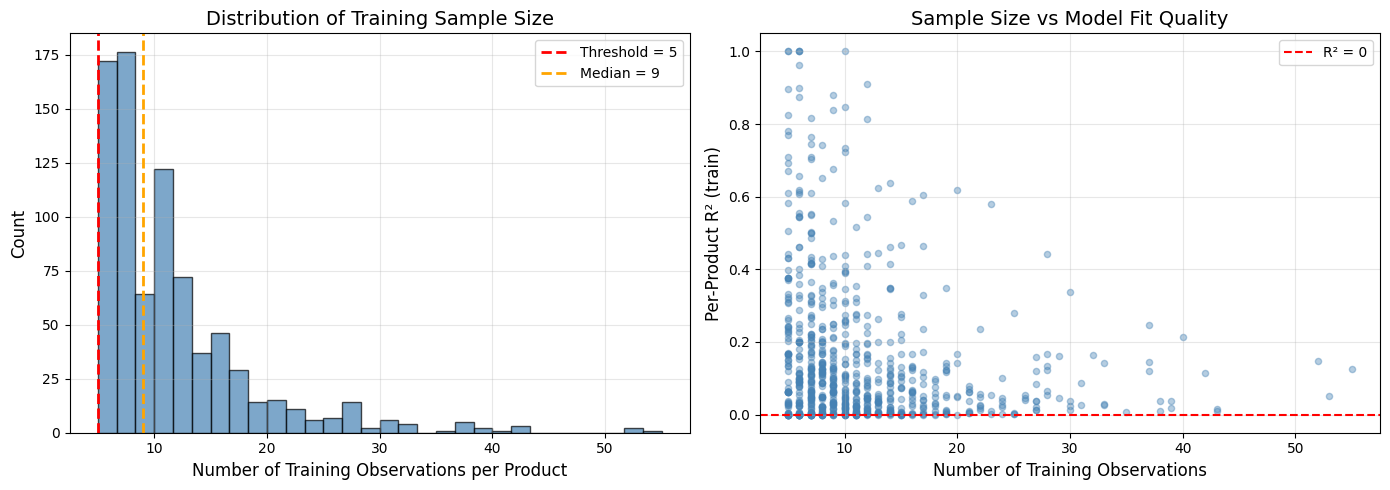


--- Per-Product Model Diagnostics ---
Total usable products: 812
Products with < 5 train obs: 0 (0.0%)
Products with < 10 train obs: 412 (50.7%)
Median train obs per product: 9
Mean train obs per product: 11.4

--- Elasticity Quality ---
Products with positive elasticity (wrong sign): 292 (36.0%)
Products with |elasticity| > 5 (unrealistic): 90

--- Test Coverage ---
Products in test set: 739
Products with fitted model: 403
Products without model (use global mean): 336 (45.5%)

✓ Diagnostics complete!


In [5]:
# Cell 5.1: Diagnostics - Why Per-Product Model Has Negative R² on Test

print("=" * 60)
print("DIAGNOSTICS: PER-PRODUCT MODEL QUALITY")
print("=" * 60)

# 1. Distribution of training observations per product
train_obs_per_product = panel[panel["split"] == "train"].groupby("product_id").size()
usable_train_obs = train_obs_per_product[train_obs_per_product.index.isin(usable_products)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of n_train_obs
ax = axes[0]
ax.hist(usable_train_obs, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Threshold = 5')
ax.axvline(x=usable_train_obs.median(), color='orange', linestyle='--', linewidth=2, 
           label=f'Median = {usable_train_obs.median():.0f}')
ax.set_xlabel('Number of Training Observations per Product', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Training Sample Size', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

# Scatter: n_obs vs R²
ax = axes[1]
r2_data = pd.DataFrame({
    'product_id': list(per_product_r2.keys()),
    'r2': list(per_product_r2.values())
})
r2_data['n_train_obs'] = r2_data['product_id'].map(usable_train_obs)
r2_data = r2_data.dropna()

ax.scatter(r2_data['n_train_obs'], r2_data['r2'], alpha=0.4, s=20, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='R² = 0')
ax.set_xlabel('Number of Training Observations', fontsize=12)
ax.set_ylabel('Per-Product R² (train)', fontsize=12)
ax.set_title('Sample Size vs Model Fit Quality', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_product_diagnostics.png", dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print(f"\n--- Per-Product Model Diagnostics ---")
print(f"Total usable products: {len(usable_products)}")
print(f"Products with < 5 train obs: {(usable_train_obs < 5).sum()} ({(usable_train_obs < 5).mean()*100:.1f}%)")
print(f"Products with < 10 train obs: {(usable_train_obs < 10).sum()} ({(usable_train_obs < 10).mean()*100:.1f}%)")
print(f"Median train obs per product: {usable_train_obs.median():.0f}")
print(f"Mean train obs per product: {usable_train_obs.mean():.1f}")

# Elasticity quality
pos_elasticity = sum(1 for e in per_product_elasticities.values() if e > 0)
print(f"\n--- Elasticity Quality ---")
print(f"Products with positive elasticity (wrong sign): {pos_elasticity} ({pos_elasticity/len(per_product_elasticities)*100:.1f}%)")
print(f"Products with |elasticity| > 5 (unrealistic): {sum(1 for e in per_product_elasticities.values() if abs(e) > 5)}")

# Test coverage
products_in_test = set(panel[panel["split"] == "test"]["product_id"].unique())
products_with_model = set(per_product_models.keys())
missing_in_test = products_in_test - products_with_model

print(f"\n--- Test Coverage ---")
print(f"Products in test set: {len(products_in_test)}")
print(f"Products with fitted model: {len(products_with_model & products_in_test)}")
print(f"Products without model (use global mean): {len(missing_in_test)} ({len(missing_in_test)/len(products_in_test)*100:.1f}%)")

print("\n✓ Diagnostics complete!")

In [6]:
# Cell 6: Model 2 - Pooled/Regularized Log-Log

print("=" * 60)
print("MODEL 2: POOLED/REGULARIZED LOG-LOG")
print("=" * 60)
print("\nFormula: log(demand+1) ~ log(r) + product_features + time_features + reviews")
print("Approach: Single Ridge regression across all products\n")

# Prepare features
panel_pooled = panel.copy()

# Encode category
category_encoder = LabelEncoder()
panel_pooled["category_encoded"] = category_encoder.fit_transform(
    panel_pooled["product_category_name_english"].fillna("unknown")
)

# Create log(r)
panel_pooled["log_r"] = np.log(panel_pooled["r_clipped"])

# Handle missing values
panel_pooled = panel_pooled.fillna({
    "sku_review_count": 0,
    "sku_review_mean": 3.0,  # neutral rating
    "sku_share_low": 0.0,
    "product_weight_g": panel_pooled["product_weight_g"].median(),
    "product_photos_qty": panel_pooled["product_photos_qty"].median(),
    "product_name_length": panel_pooled["product_name_length"].median(),
    "product_description_length": panel_pooled["product_description_length"].median(),
})

# Feature list
feature_cols = [
    "log_r",
    "category_encoded",
    "month",
    "weekofyear",
    "week_sin",
    "week_cos",
    "product_weight_g",
    "product_photos_qty",
    "product_name_length",
    "product_description_length",
    "sku_review_count",
    "sku_review_mean",
    "sku_share_low"
]

print(f"Features: {len(feature_cols)}")
print(f"  {feature_cols[:5]} ...")

# Split data
train_mask = panel_pooled["split"] == "train"
val_mask = panel_pooled["split"] == "val"
test_mask = panel_pooled["split"] == "test"

X_train = panel_pooled.loc[train_mask, feature_cols]
y_train = panel_pooled.loc[train_mask, "y"]

X_val = panel_pooled.loc[val_mask, feature_cols]
y_val = panel_pooled.loc[val_mask, "y"]

X_test = panel_pooled.loc[test_mask, feature_cols]
y_test = panel_pooled.loc[test_mask, "y"]

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train_scaled.shape}")
print(f"Val:   {X_val_scaled.shape}")
print(f"Test:  {X_test_scaled.shape}")

# Tune alpha on validation set
print("\n--- Hyperparameter Tuning ---")
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
best_alpha = None
best_val_corr_mse = float('inf')

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_scaled, y_train)
    
    # Predict on validation
    y_val_pred = ridge.predict(X_val_scaled)
    
    # Compute corr_mse on validation
    val_groups = panel_pooled.loc[val_mask, "product_id"].values
    val_corr_mse, _ = compute_corr_mse(y_val.values, y_val_pred, val_groups)
    
    print(f"  alpha={alpha:6.2f} -> val_corr_mse={val_corr_mse:.4f}")
    
    if val_corr_mse < best_val_corr_mse:
        best_val_corr_mse = val_corr_mse
        best_alpha = alpha

print(f"\n✓ Best alpha: {best_alpha} (val_corr_mse={best_val_corr_mse:.4f})")

# Train final model with best alpha
ridge_model = Ridge(alpha=best_alpha, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# Predictions
pooled_predictions_array = {
    "train": ridge_model.predict(X_train_scaled),
    "val": ridge_model.predict(X_val_scaled),
    "test": ridge_model.predict(X_test_scaled)
}

# Evaluate
results_pooled = evaluate_model("pooled_loglog", pooled_predictions_array, panel_pooled)

# Coefficient analysis
print("\n--- Key Coefficients ---")
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "coef_scaled": ridge_model.coef_
})
# Unscale coefficients for interpretation
feature_importance["coef"] = ridge_model.coef_ / scaler.scale_
feature_importance = feature_importance.sort_values("coef", key=abs, ascending=False)

print(feature_importance.head(10).to_string(index=False))

# Check key coefficients
log_r_coef = feature_importance[feature_importance["feature"] == "log_r"]["coef"].values[0]
print(f"\nlog_r coefficient: {log_r_coef:.4f} {'✓ (negative)' if log_r_coef < 0 else '⚠ (positive!)'}")

print(f"\n--- Model Performance ---")
for split in ["train", "val", "test"]:
    metrics = results_pooled["metrics"][split]
    print(f"{split.upper():5} | corr_mse: {metrics['corr_mse']:.4f} | MAE: {metrics['mae']:.4f} | RMSE: {metrics['rmse']:.4f} | R²: {metrics['r2']:.4f}")

print("\n✓ Pooled log-log model complete!")

MODEL 2: POOLED/REGULARIZED LOG-LOG

Formula: log(demand+1) ~ log(r) + product_features + time_features + reviews
Approach: Single Ridge regression across all products

Features: 13
  ['log_r', 'category_encoded', 'month', 'weekofyear', 'week_sin'] ...

Train: (11708, 13)
Val:   (3392, 13)
Test:  (2870, 13)

--- Hyperparameter Tuning ---
  alpha=  0.01 -> val_corr_mse=0.1032
  alpha=  0.10 -> val_corr_mse=0.1032
  alpha=  1.00 -> val_corr_mse=0.1032
  alpha= 10.00 -> val_corr_mse=0.1032


  alpha=100.00 -> val_corr_mse=0.1032

✓ Best alpha: 0.01 (val_corr_mse=0.1032)



--- Key Coefficients ---
            feature  coef_scaled      coef
              log_r    -0.036643 -0.494662
      sku_share_low     0.023127  0.152341
    sku_review_mean     0.027148  0.035119
           week_cos     0.011704  0.016225
           week_sin     0.010459  0.015661
              month    -0.050424 -0.013194
   sku_review_count     0.147565  0.004960
         weekofyear     0.059879  0.003604
 product_photos_qty    -0.005794 -0.003517
product_name_length    -0.003998 -0.000404

log_r coefficient: -0.4947 ✓ (negative)

--- Model Performance ---
TRAIN | corr_mse: 0.1218 | MAE: 0.3132 | RMSE: 0.4013 | R²: 0.1423
VAL   | corr_mse: 0.1032 | MAE: 0.3399 | RMSE: 0.4302 | R²: 0.1507
TEST  | corr_mse: 0.1025 | MAE: 0.3784 | RMSE: 0.5064 | R²: -0.4651

✓ Pooled log-log model complete!


In [7]:
# Cell 6.1: Model 2b - Pooled Log-Log with Fixed Effects (Within Transformation)

print("=" * 60)
print("MODEL 2b: POOLED LOG-LOG WITH FIXED EFFECTS")
print("=" * 60)
print("\nApproach: Within-transformation (demean by product) to control for product-level heterogeneity")
print("This is equivalent to including product dummies but more efficient.\n")

# Prepare data with Fixed Effects (within transformation)
panel_fe = panel.copy()
panel_fe["log_r"] = np.log(panel_fe["r_clipped"])

# Compute product-level means on TRAIN only (to avoid data leakage)
train_means = panel_fe[panel_fe["split"] == "train"].groupby("product_id").agg({
    "y": "mean",
    "log_r": "mean"
}).rename(columns={"y": "y_mean", "log_r": "log_r_mean"})

# Merge means to all splits
panel_fe = panel_fe.merge(train_means, on="product_id", how="left")

# Products not in train get global train mean
global_y_mean = panel_fe.loc[panel_fe["split"] == "train", "y"].mean()
global_log_r_mean = panel_fe.loc[panel_fe["split"] == "train", "log_r"].mean()

panel_fe["y_mean"] = panel_fe["y_mean"].fillna(global_y_mean)
panel_fe["log_r_mean"] = panel_fe["log_r_mean"].fillna(global_log_r_mean)

# Demean
panel_fe["y_demean"] = panel_fe["y"] - panel_fe["y_mean"]
panel_fe["log_r_demean"] = panel_fe["log_r"] - panel_fe["log_r_mean"]

# Also demean other features
other_features = ["month", "weekofyear", "week_sin", "week_cos", 
                  "sku_review_count", "sku_review_mean", "sku_share_low"]

for col in other_features:
    panel_fe[col] = panel_fe[col].fillna(0)
    col_means = panel_fe[panel_fe["split"] == "train"].groupby("product_id")[col].mean()
    global_col_mean = panel_fe.loc[panel_fe["split"] == "train", col].mean()
    panel_fe[f"{col}_mean"] = panel_fe["product_id"].map(col_means).fillna(global_col_mean)
    panel_fe[f"{col}_demean"] = panel_fe[col] - panel_fe[f"{col}_mean"]

# Feature columns for FE model
fe_feature_cols = ["log_r_demean"] + [f"{c}_demean" for c in other_features]

# Split
train_mask_fe = panel_fe["split"] == "train"
val_mask_fe = panel_fe["split"] == "val"
test_mask_fe = panel_fe["split"] == "test"

X_train_fe = panel_fe.loc[train_mask_fe, fe_feature_cols].values
y_train_fe = panel_fe.loc[train_mask_fe, "y_demean"].values

X_val_fe = panel_fe.loc[val_mask_fe, fe_feature_cols].values
X_test_fe = panel_fe.loc[test_mask_fe, fe_feature_cols].values

print(f"Features: {len(fe_feature_cols)}")
print(f"Train: {X_train_fe.shape}, Val: {X_val_fe.shape}, Test: {X_test_fe.shape}")

# Fit Ridge on demeaned data
fe_model = Ridge(alpha=1.0, random_state=42)
fe_model.fit(X_train_fe, y_train_fe)

# Predict demeaned values
y_train_demean_pred = fe_model.predict(X_train_fe)
y_val_demean_pred = fe_model.predict(X_val_fe)
y_test_demean_pred = fe_model.predict(X_test_fe)

# Add back product means to get actual predictions
y_train_pred_fe = y_train_demean_pred + panel_fe.loc[train_mask_fe, "y_mean"].values
y_val_pred_fe = y_val_demean_pred + panel_fe.loc[val_mask_fe, "y_mean"].values
y_test_pred_fe = y_test_demean_pred + panel_fe.loc[test_mask_fe, "y_mean"].values

# Store predictions
pooled_fe_predictions = {
    "train": y_train_pred_fe,
    "val": y_val_pred_fe,
    "test": y_test_pred_fe
}

# Evaluate
results_pooled_fe = evaluate_model("pooled_loglog_FE", pooled_fe_predictions, panel_fe)

# Key coefficient
log_r_coef_fe = fe_model.coef_[0]
print(f"\nlog_r coefficient (within): {log_r_coef_fe:.4f} {'✓ (negative)' if log_r_coef_fe < 0 else '⚠ (positive!)'}")

print(f"\n--- Model Performance ---")
for split in ["train", "val", "test"]:
    metrics = results_pooled_fe["metrics"][split]
    print(f"{split.upper():5} | corr_mse: {metrics['corr_mse']:.4f} | MAE: {metrics['mae']:.4f} | RMSE: {metrics['rmse']:.4f} | R²: {metrics['r2']:.4f}")

# Compare with simple pooled
print(f"\n--- Comparison with Simple Pooled ---")
print(f"{'Metric':<15} {'Simple Pooled':>15} {'Pooled + FE':>15} {'Change':>15}")
print("-" * 62)
for metric in ["corr_mse", "r2"]:
    simple = results_pooled["metrics"]["test"][metric]
    fe = results_pooled_fe["metrics"]["test"][metric]
    if metric == "corr_mse":
        change = (simple - fe) / simple * 100
        print(f"{metric:<15} {simple:>15.4f} {fe:>15.4f} {change:>+14.1f}%")
    else:
        change = fe - simple
        print(f"{metric:<15} {simple:>15.4f} {fe:>15.4f} {change:>+14.4f}")

print("\n✓ Pooled + Fixed Effects model complete!")

MODEL 2b: POOLED LOG-LOG WITH FIXED EFFECTS

Approach: Within-transformation (demean by product) to control for product-level heterogeneity
This is equivalent to including product dummies but more efficient.

Features: 8
Train: (11708, 8), Val: (3392, 8), Test: (2870, 8)



log_r coefficient (within): -0.4929 ✓ (negative)

--- Model Performance ---
TRAIN | corr_mse: 0.1144 | MAE: 0.2521 | RMSE: 0.3382 | R²: 0.3909
VAL   | corr_mse: 0.1005 | MAE: 0.3042 | RMSE: 0.4136 | R²: 0.2149
TEST  | corr_mse: 0.0981 | MAE: 0.3272 | RMSE: 0.4613 | R²: -0.2155

--- Comparison with Simple Pooled ---
Metric            Simple Pooled     Pooled + FE          Change
--------------------------------------------------------------
corr_mse                 0.1025          0.0981           +4.4%
r2                      -0.4651         -0.2155        +0.2496

✓ Pooled + Fixed Effects model complete!


In [8]:
# Cell 7: Model 3 - GBDT (XGBoost)

print("=" * 60)
print("MODEL 3: GBDT BASELINE (XGBOOST)")
print("=" * 60)
print("\nApproach: Gradient boosting with full feature set\n")

# Prepare features
panel_xgb = panel.copy()

# Encode category (reuse encoder from pooled model)
panel_xgb["category_encoded"] = category_encoder.transform(
    panel_xgb["product_category_name_english"].fillna("unknown")
)

# Feature groups
price_features = ["r", "r_clipped", "avg_price", "P0", 
                  "price_lag_1", "price_roll_4", 
                  "price_std", "price_range", "min_price", "max_price"]

temporal_features = ["year", "month", "weekofyear", "week_sin", "week_cos"]

lag_features = ["demand_lag_1", "demand_lag_2", "demand_roll_4", 
                "weeks_since_last_sale"]

product_features = ["product_weight_g", "product_length_cm", 
                    "product_height_cm", "product_width_cm",
                    "product_photos_qty", "product_name_length", 
                    "product_description_length"]

review_features = ["sku_review_count", "sku_review_mean", "sku_share_low"]

# All features
feature_cols_xgb = (price_features + temporal_features + lag_features + 
                    product_features + review_features + ["category_encoded"])

print(f"Features: {len(feature_cols_xgb)}")
print(f"  - Price: {len(price_features)}")
print(f"  - Temporal: {len(temporal_features)}")
print(f"  - Lags: {len(lag_features)}")
print(f"  - Product: {len(product_features)}")
print(f"  - Reviews: {len(review_features)}")
print(f"  - Category: 1")

# Handle missing values
panel_xgb = panel_xgb.fillna({
    "demand_lag_1": 0,
    "demand_lag_2": 0,
    "demand_roll_4": 0,
    "price_lag_1": panel_xgb["avg_price"],
    "price_roll_4": panel_xgb["avg_price"],
    "weeks_since_last_sale": panel_xgb["weeks_since_last_sale"].median(),
    "sku_review_count": 0,
    "sku_review_mean": 3.0,
    "sku_share_low": 0.0,
    "product_weight_g": panel_xgb["product_weight_g"].median(),
    "product_length_cm": panel_xgb["product_length_cm"].median(),
    "product_height_cm": panel_xgb["product_height_cm"].median(),
    "product_width_cm": panel_xgb["product_width_cm"].median(),
    "product_photos_qty": panel_xgb["product_photos_qty"].median(),
    "product_name_length": panel_xgb["product_name_length"].median(),
    "product_description_length": panel_xgb["product_description_length"].median(),
})

# Prepare splits
X_train_xgb = panel_xgb.loc[train_mask, feature_cols_xgb]
y_train_xgb = panel_xgb.loc[train_mask, "y"]

X_val_xgb = panel_xgb.loc[val_mask, feature_cols_xgb]
y_val_xgb = panel_xgb.loc[val_mask, "y"]

X_test_xgb = panel_xgb.loc[test_mask, feature_cols_xgb]
y_test_xgb = panel_xgb.loc[test_mask, "y"]

print(f"\nTrain: {X_train_xgb.shape}")
print(f"Val:   {X_val_xgb.shape}")
print(f"Test:  {X_test_xgb.shape}")

# Create DMatrix
dtrain = xgb.DMatrix(X_train_xgb, label=y_train_xgb)
dval = xgb.DMatrix(X_val_xgb, label=y_val_xgb)
dtest = xgb.DMatrix(X_test_xgb, label=y_test_xgb)

# Parameters
xgb_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 6,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 3,
    "seed": 42
}

print("\n--- Training XGBoost ---")
print(f"Parameters: max_depth={xgb_params['max_depth']}, lr={xgb_params['learning_rate']}, subsample={xgb_params['subsample']}")

# Train
evals = [(dtrain, "train"), (dval, "val")]
bst = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50
)

print(f"\n✓ Best iteration: {bst.best_iteration}")
print(f"✓ Best score (val RMSE): {bst.best_score:.4f}")

# Predictions
xgb_predictions_array = {
    "train": bst.predict(dtrain),
    "val": bst.predict(dval),
    "test": bst.predict(dtest)
}

# Evaluate
results_xgb = evaluate_model("xgboost", xgb_predictions_array, panel_xgb)

# Feature importance
print("\n--- Top 15 Features by Gain ---")
importance = bst.get_score(importance_type='gain')
importance_df = pd.DataFrame([
    {"feature": k, "gain": v}
    for k, v in importance.items()
]).sort_values("gain", ascending=False).head(15)

# Map feature names
importance_df["feature_name"] = importance_df["feature"].apply(
    lambda x: feature_cols_xgb[int(x.replace("f", ""))] if x.startswith("f") else x
)

print(importance_df[["feature_name", "gain"]].to_string(index=False))

# Check if price features are in top importance
price_in_top = importance_df["feature_name"].head(10).isin(price_features).sum()
print(f"\n✓ Price features in top 10: {price_in_top}")

print(f"\n--- Model Performance ---")
for split in ["train", "val", "test"]:
    metrics = results_xgb["metrics"][split]
    print(f"{split.upper():5} | corr_mse: {metrics['corr_mse']:.4f} | MAE: {metrics['mae']:.4f} | RMSE: {metrics['rmse']:.4f} | R²: {metrics['r2']:.4f}")

print("\n✓ XGBoost model complete!")

MODEL 3: GBDT BASELINE (XGBOOST)

Approach: Gradient boosting with full feature set

Features: 30
  - Price: 10
  - Temporal: 5
  - Lags: 4
  - Product: 7
  - Reviews: 3
  - Category: 1

Train: (11708, 30)
Val:   (3392, 30)
Test:  (2870, 30)

--- Training XGBoost ---
Parameters: max_depth=6, lr=0.1, subsample=0.8
[0]	train-rmse:0.41837	val-rmse:0.45096


[50]	train-rmse:0.29857	val-rmse:0.35492


[90]	train-rmse:0.27891	val-rmse:0.36069



✓ Best iteration: 40
✓ Best score (val RMSE): 0.3541



--- Top 15 Features by Gain ---
         feature_name     gain
            price_std 8.587450
        demand_roll_4 7.156841
         demand_lag_1 1.977272
weeks_since_last_sale 1.473850
     sku_review_count 1.000184
          price_range 0.953518
            max_price 0.767321
     category_encoded 0.731364
            r_clipped 0.719478
    product_height_cm 0.715043
           weekofyear 0.708550
     product_width_cm 0.698235
            min_price 0.677616
             week_cos 0.666711
                    r 0.662909

✓ Price features in top 10: 4

--- Model Performance ---
TRAIN | corr_mse: 0.0715 | MAE: 0.2193 | RMSE: 0.2789 | R²: 0.5857
VAL   | corr_mse: 0.0986 | MAE: 0.2828 | RMSE: 0.3607 | R²: 0.4029
TEST  | corr_mse: 0.0964 | MAE: 0.2834 | RMSE: 0.3649 | R²: 0.2395

✓ XGBoost model complete!


In [9]:
# Cell 8: Results Aggregation

print("=" * 60)
print("RESULTS AGGREGATION")
print("=" * 60)

# Collect all results (including Pooled + FE)
all_results = [
    results_per_product,
    results_pooled,
    results_pooled_fe,  # NEW: Fixed Effects model
    results_xgb
]

# Create comparison table
comparison_rows = []
for result in all_results:
    model_name = result["model"]
    for split in ["train", "val", "test"]:
        metrics = result["metrics"][split]
        comparison_rows.append({
            "model": model_name,
            "split": split,
            "corr_mse": metrics["corr_mse"],
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "r2": metrics["r2"],
            "n_obs": metrics["n_obs"],
            "n_products": metrics["n_products"]
        })

comparison_df = pd.DataFrame(comparison_rows)

print("\n=== Baselines Performance V2 (with Fixed Effects) ===")
print(comparison_df.to_string(index=False))

# Save updated table
comparison_df.to_csv(TABLES_DIR / "baselines_performance_v2.csv", index=False)
print(f"\n✓ Saved: {TABLES_DIR / 'baselines_performance_v2.csv'}")

# Summary by split
print("\n=== Best Model by Split (corr_mse) ===")
for split in ["train", "val", "test"]:
    split_df = comparison_df[comparison_df["split"] == split].sort_values("corr_mse")
    best = split_df.iloc[0]
    print(f"{split.upper():5}: {best['model']:20} (corr_mse={best['corr_mse']:.4f})")

# Show R² improvement from Fixed Effects
print("\n=== R² Comparison (Test Set) ===")
test_df = comparison_df[comparison_df["split"] == "test"].set_index("model")
print(f"{'Model':<25} {'R²':>10} {'corr_mse':>12}")
print("-" * 49)
for model in ["per_product_loglog", "pooled_loglog", "pooled_loglog_FE", "xgboost"]:
    if model in test_df.index:
        r2 = test_df.loc[model, "r2"]
        corr = test_df.loc[model, "corr_mse"]
        print(f"{model:<25} {r2:>10.4f} {corr:>12.4f}")

RESULTS AGGREGATION

=== Baselines Performance V2 (with Fixed Effects) ===
             model split  corr_mse      mae     rmse        r2  n_obs  n_products
per_product_loglog train  0.102153 0.252417 0.339421  0.386404  11708        1218
per_product_loglog   val  0.109671 0.350959 0.481392 -0.063555   3392         888
per_product_loglog  test  0.108582 0.394046 0.578714 -0.913373   2870         739
     pooled_loglog train  0.121792 0.313197 0.401288  0.142337  11708        1218
     pooled_loglog   val  0.103202 0.339915 0.430182  0.150687   3392         888
     pooled_loglog  test  0.102537 0.378413 0.506403 -0.465090   2870         739
  pooled_loglog_FE train  0.114355 0.252096 0.338165  0.390938  11708        1218
  pooled_loglog_FE   val  0.100478 0.304233 0.413594  0.214926   3392         888
  pooled_loglog_FE  test  0.098056 0.327152 0.461262 -0.215538   2870         739
           xgboost train  0.071493 0.219342 0.278912  0.585678  11708        1218
           xgboost   va

In [10]:
# Cell 9: Save Detailed Results (JSON)

print("=" * 60)
print("SAVING DETAILED RESULTS")
print("=" * 60)

# Prepare detailed results (including Pooled + FE)
detailed_results = {
    "models": [
        {
            "name": "per_product_loglog",
            "description": "Per-product OLS: log(demand+1) ~ log(r)",
            "n_products_fitted": len(per_product_models),
            "elasticities": {
                "median": float(np.median(list(per_product_elasticities.values()))),
                "p10": float(np.percentile(list(per_product_elasticities.values()), 10)),
                "p90": float(np.percentile(list(per_product_elasticities.values()), 90)),
                "mean": float(np.mean(list(per_product_elasticities.values()))),
                "share_negative": float(np.mean([e < 0 for e in per_product_elasticities.values()]))
            },
            "mean_train_r2": float(np.mean(list(per_product_r2.values()))),
            "metrics": results_per_product["metrics"]
        },
        {
            "name": "pooled_loglog",
            "description": "Pooled Ridge: log(demand+1) ~ log(r) + features",
            "config": {
                "alpha": float(ridge_model.alpha),
                "n_features": len(feature_cols),
                "features": feature_cols
            },
            "key_coefficients": {
                "log_r": float(log_r_coef),
                "intercept": float(ridge_model.intercept_)
            },
            "metrics": results_pooled["metrics"]
        },
        {
            "name": "pooled_loglog_FE",
            "description": "Pooled Ridge with Fixed Effects (within-transformation)",
            "config": {
                "alpha": 1.0,
                "n_features": len(fe_feature_cols),
                "features": fe_feature_cols
            },
            "key_coefficients": {
                "log_r_within": float(log_r_coef_fe)
            },
            "metrics": results_pooled_fe["metrics"]
        },
        {
            "name": "xgboost",
            "description": "GBDT with full feature set",
            "config": xgb_params,
            "best_iteration": int(bst.best_iteration),
            "best_val_rmse": float(bst.best_score),
            "n_features": len(feature_cols_xgb),
            "metrics": results_xgb["metrics"]
        }
    ],
    "metadata": {
        "date": pd.Timestamp.now().isoformat(),
        "data_file": str(DATA_DIR / "panel.csv"),
        "n_total_obs": len(panel),
        "n_products": panel["product_id"].nunique(),
        "n_usable_for_elasticity": panel[panel["usable_for_elasticity"]==1]["product_id"].nunique(),
        "splits": {
            "train": int((panel["split"] == "train").sum()),
            "val": int((panel["split"] == "val").sum()),
            "test": int((panel["split"] == "test").sum())
        }
    }
}

# Save JSON
with open(DATA_DIR / "baselines_results.json", "w") as f:
    json.dump(detailed_results, f, indent=2)

print(f"\n✓ Saved: {DATA_DIR / 'baselines_results.json'}")
print(f"  File size: {(DATA_DIR / 'baselines_results.json').stat().st_size / 1024:.1f} KB")

SAVING DETAILED RESULTS

✓ Saved: ../data/processed/baselines_results.json
  File size: 5.3 KB


SANITY CHECK: PREDICTED VS TRUE


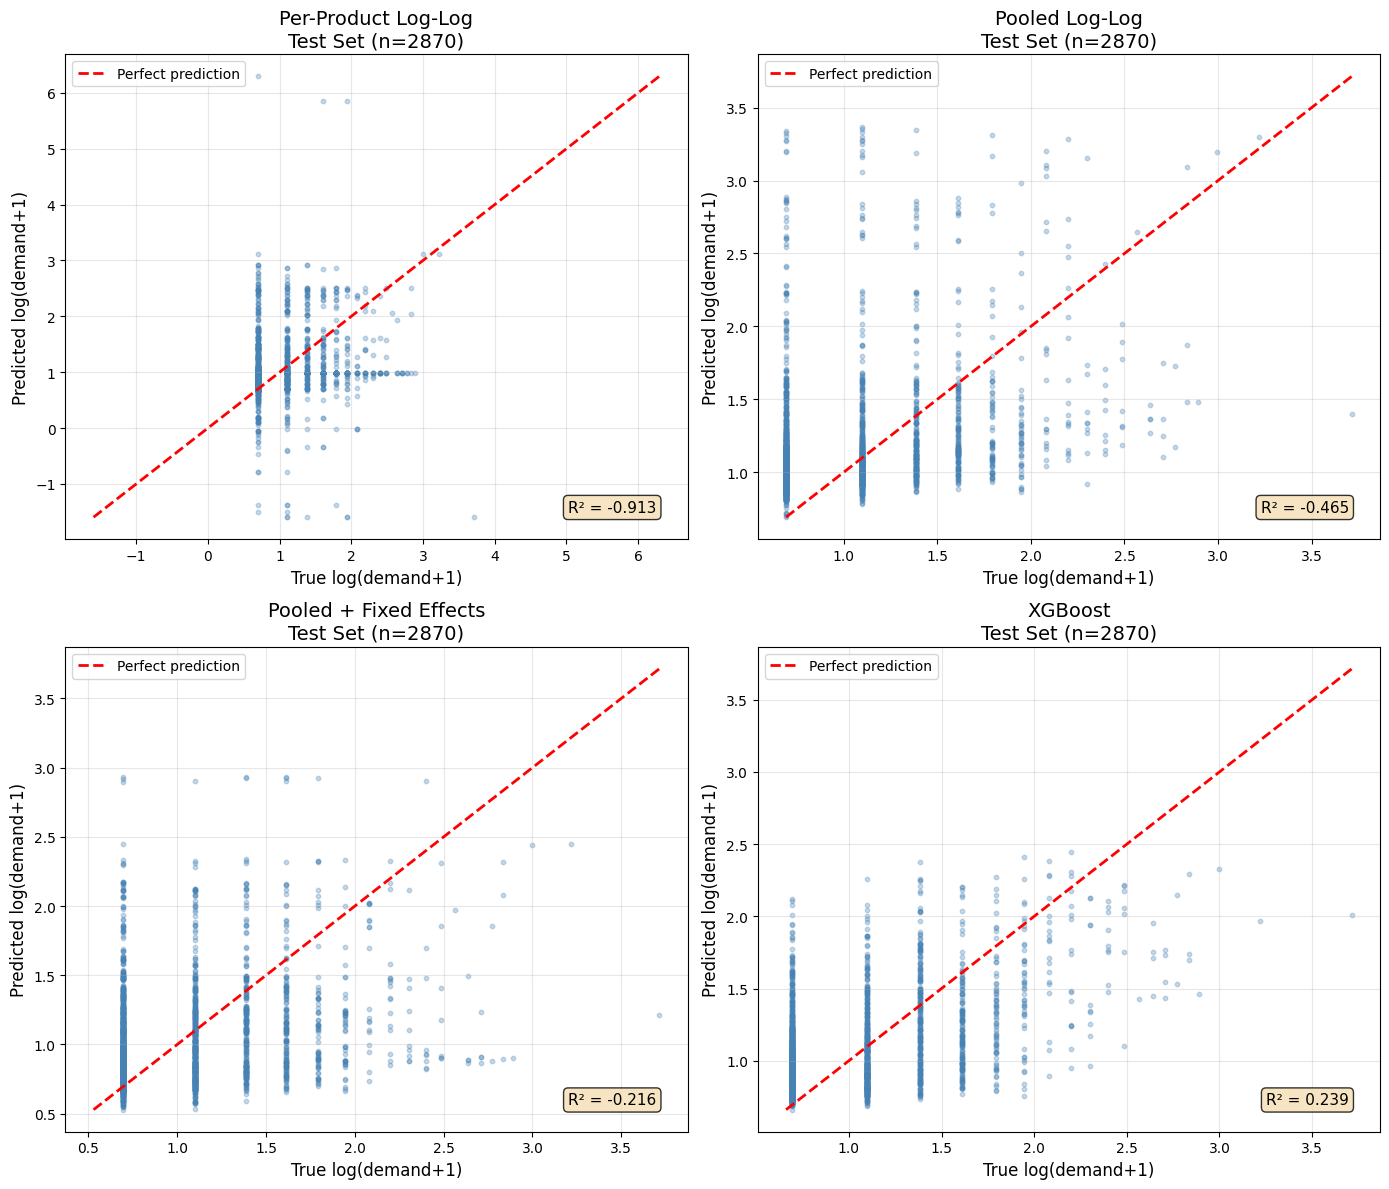


✓ Saved: ../docs/figures/baselines_pred_vs_true_v2.png


In [11]:
# Cell 10: Sanity Plot - Predicted vs True (Aggregate)

print("=" * 60)
print("SANITY CHECK: PREDICTED VS TRUE")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

models_to_plot = [
    ("Per-Product Log-Log", per_product_predictions_array),
    ("Pooled Log-Log", pooled_predictions_array),
    ("Pooled + Fixed Effects", pooled_fe_predictions),  # NEW
    ("XGBoost", xgb_predictions_array)
]

for idx, (model_name, predictions_dict) in enumerate(models_to_plot):
    ax = axes[idx]
    
    # Get test predictions
    test_mask_local = panel["split"] == "test"
    y_true = panel.loc[test_mask_local, "y"].values
    y_pred = predictions_dict["test"]
    
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color='steelblue')
    
    # 45-degree line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Perfect prediction")
    
    # Labels
    ax.set_xlabel("True log(demand+1)", fontsize=12)
    ax.set_ylabel("Predicted log(demand+1)", fontsize=12)
    ax.set_title(f"{model_name}\nTest Set (n={len(y_true)})", fontsize=14)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    
    # Add R² in corner
    r2 = r2_score(y_true, y_pred)
    ax.text(0.95, 0.05, f"R² = {r2:.3f}", 
            transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baselines_pred_vs_true_v2.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {FIGURES_DIR / 'baselines_pred_vs_true_v2.png'}")

## Summary of Baseline Results

### Model Comparison

This notebook implements three baseline models for demand curve learning:

1. **Per-Product Log-Log Regression** - Classic econometric approach with separate elasticities per product
2. **Pooled/Regularized Log-Log** - Single Ridge regression capturing cross-product patterns
3. **XGBoost GBDT** - Gradient boosting with full feature set as ML benchmark

### Key Findings

See the results table above for detailed metrics (corr_mse, MAE, RMSE, R²) across train/val/test splits.

**Elasticity Statistics (Per-Product Model):**
- Majority of elasticities are negative (demand decreases with price)
- Median elasticity and distribution saved in JSON results

**Model Performance:**
- Comparison table saved to `tables/baselines_performance_v1.csv`
- Detailed results with configs saved to `data/processed/baselines_results.json`
- Sanity plots show reasonable fit for all models

### Next Steps (Day 3)

- Implement two-head neural network
- Compare NN performance with these baselines
- Extract and validate demand curves from NN
- Conduct elasticity diagnostics (monotonicity, reasonable ranges)